# 140 — Focused search for direct P, S, and surface-wave energy

This notebook is the authoritative direct-seismic-wave search. Notebook 130 remains responsible for instrument-coordinate checks, Z/N/E-to-Z/R/T rotation, broad polarization products, and overview spectrograms. This notebook consumes the unfiltered Z/R/T Stream written by Notebook 130 and focuses on onset timing and source-to-receiver apparent speeds.

The workflow deliberately avoids assigning P, S, Rayleigh, or Love labels from timing alone. It:

1. compares causal and zero-phase filtering;
2. detects amplitude onsets without preselecting 1.1 or 2.0 s;
3. uses trailing, amplitude-gated polarization windows so polarization cannot anticipate an onset;
4. measures radiality, incidence, Z–R coherence and phase;
5. constructs noise-normalized focused spectrograms;
6. estimates frequency-dependent group-delay proxies; and
7. optionally stacks isolated A-quality events aligned by their infrasound-derived source times.

With one three-component seismometer, travel time gives a **path-average apparent velocity**. Frequency-dependent envelope delays give a **group-velocity proxy**. They do not independently determine true surface-wave phase velocity.

Source origins are adopted infrasound-reduced coordinates, not independent
source clock observations. The causal bandpass/RMS in this notebook does not
make the preceding response correction fully causal. Robust-MAD thresholds
are empirical screening levels, not Gaussian false-alarm probabilities.
No phase boundaries are introduced or changed.


## 1. Imports, project paths, and authoritative inputs


In [1]:
from __future__ import annotations

import json
import sys
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from obspy import Stream, Trace, UTCDateTime, read
from scipy.ndimage import uniform_filter1d
from scipy.signal import find_peaks, hilbert, spectrogram

def find_project_root(start):
    current = Path(start).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "modules" / "project_config.py").is_file():
            return candidate
    raise FileNotFoundError(
        f"Could not find modules/project_config.py above {current}"
    )


project_root = find_project_root(Path.cwd())
project_root_text = str(project_root)
sys.path = [entry for entry in sys.path if entry != project_root_text]
sys.path.insert(0, project_root_text)

# A long-lived Jupyter kernel may still hold an older project_config after
# the file has been edited. Remove the cached package and import the copy
# belonging to the repository that contains this notebook.
sys.modules.pop("modules.project_config", None)
sys.modules.pop("modules", None)
importlib.invalidate_caches()
from modules import project_config as config

expected_config_file = (
    project_root / "modules" / "project_config.py"
).resolve()
active_config_file = Path(config.__file__).resolve()
if active_config_file != expected_config_file:
    raise RuntimeError(
        "Imported the wrong project_config.py: "
        f"{active_config_file}; expected {expected_config_file}"
    )

ANALYSIS_CONFIG_FILE = config.NB010_DIR / "analysis_configuration.json"
WEATHER_SUMMARY_FILE = config.NB020_DIR / "weather_acoustic_summary.csv"
NOTEBOOK12_ROOT = config.NB130_DIR
ZRT_STREAM_FILE = NOTEBOOK12_ROOT / "seismic_zrt.pkl"

for label, path in {
    "Notebook 010 analysis configuration": ANALYSIS_CONFIG_FILE,
    "Notebook 020 weather summary": WEATHER_SUMMARY_FILE,
    "Notebook 130 unfiltered Z/R/T Stream": ZRT_STREAM_FILE,
}.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing {label}: {path}")

analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())
weather_rows = pd.read_csv(WEATHER_SUMMARY_FILE)
if len(weather_rows) != 1:
    raise ValueError("Expected one adopted weather summary row")
weather_summary = weather_rows.iloc[0]

OUTPUT_ROOT = config.NB140_DIR
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
config.NB140_DIR.mkdir(parents=True, exist_ok=True)

ONSET_CANDIDATE_TABLE = OUTPUT_ROOT / "onset_candidates.csv"
ONSET_SUMMARY_TABLE = OUTPUT_ROOT / "onset_summary_by_band.csv"
POLARIZATION_TABLE = OUTPUT_ROOT / "trailing_polarization.csv"
POLARIZATION_SUMMARY_TABLE = OUTPUT_ROOT / "polarization_confirmation_summary.csv"
GROUP_DELAY_TABLE = OUTPUT_ROOT / "frequency_dependent_group_delay.csv"
STACK_EVENT_TABLE = OUTPUT_ROOT / "isolated_stack_events.csv"
STACK_LONG_TABLE = OUTPUT_ROOT / "isolated_event_stack.csv"
SUMMARY_JSON = OUTPUT_ROOT / "direct_seismic_search_summary.json"

ONSET_FIGURE = config.NB140_DIR / "upper_stage_onset_and_polarization.pdf"
PHASE_DIAGNOSTIC_FIGURE = config.NB140_DIR / "upper_stage_phase_discrimination.pdf"
SPECTROGRAM_FIGURE = config.NB140_DIR / "upper_stage_noise_normalized_spectrogram.pdf"
GROUP_DELAY_FIGURE = config.NB140_DIR / "upper_stage_group_delay_proxy.pdf"
STACK_FIGURE = config.NB140_DIR / "isolated_event_source_aligned_stack.pdf"

print("Notebook 130 Z/R/T input:", ZRT_STREAM_FILE)
print("Output directory:", OUTPUT_ROOT)


Notebook 130 Z/R/T input: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/130_analyze_seismic_polarization/seismic_zrt.pkl
Output directory: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/140_search_for_direct_seismic_waves


## 2. Analysis controls


In [2]:
EVENT_KEY = "upper_stage"
if EVENT_KEY not in config.SOURCE_EVENT_TIMES:
    raise KeyError(f"SOURCE_EVENT_TIMES lacks {EVENT_KEY!r}")

UPPER_STAGE_SOURCE_TIME = UTCDateTime(config.SOURCE_EVENT_TIMES[EVENT_KEY])
LOWER_STAGE_SOURCE_TIME = UTCDateTime(config.SOURCE_EVENT_TIMES["lower_stage"])

SOURCE_TO_RECEIVER_DISTANCE_M = float(
    analysis_config["array_reference"]["distance_m"]
)
METEOROLOGICAL_EFFECTIVE_SOUND_SPEED_MPS = float(
    weather_summary["effective_sound_speed_mps"]
)
PREDICTED_ACOUSTIC_DELAY_S = (
    SOURCE_TO_RECEIVER_DISTANCE_M
    / METEOROLOGICAL_EFFECTIVE_SOUND_SPEED_MPS
)
LOWER_STAGE_SOURCE_OFFSET_S = float(
    LOWER_STAGE_SOURCE_TIME - UPPER_STAGE_SOURCE_TIME
)

# The focused interval ends before the next named source and before the
# predicted upper-stage airwave. Padding is retained internally for filtering.
NOISE_WINDOW_S = (-5.0, -0.50)
DISPLAY_WINDOW_S = (-1.0, 3.45)
SEARCH_WINDOW_S = (0.20, 3.40)
FOCUSED_END_S = min(
    DISPLAY_WINDOW_S[1],
    LOWER_STAGE_SOURCE_OFFSET_S - 0.10,
    PREDICTED_ACOUSTIC_DELAY_S - 0.20,
)

# Band-specific timing controls. Polarization windows are trailing windows and
# are deliberately longer at low frequency.
DIRECT_SEARCH_BANDS = {
    "low_0p8_3": {
        "freqmin_hz": 0.8, "freqmax_hz": 3.0,
        "rms_smooth_s": 0.20, "persistence_s": 0.20,
        "polarization_window_s": 1.00,
    },
    "mid_3_8": {
        "freqmin_hz": 3.0, "freqmax_hz": 8.0,
        "rms_smooth_s": 0.10, "persistence_s": 0.12,
        "polarization_window_s": 0.40,
    },
    "high_8_20": {
        "freqmin_hz": 8.0, "freqmax_hz": 20.0,
        "rms_smooth_s": 0.05, "persistence_s": 0.08,
        "polarization_window_s": 0.20,
    },
    "very_high_20_45": {
        "freqmin_hz": 20.0, "freqmax_hz": 45.0,
        "rms_smooth_s": 0.025, "persistence_s": 0.05,
        "polarization_window_s": 0.10,
    },
}

FILTER_CORNERS = 2
AMPLITUDE_SIGMA_THRESHOLDS = (4.0, 5.0, 6.0)
STA_LTA_ON_THRESHOLD = 3.0
STA_LTA_OFF_THRESHOLD = 1.5

POLARIZATION_AMPLITUDE_SIGMA = 4.0
POLARIZATION_MIN_RECTILINEARITY = 0.70
POLARIZATION_MIN_DOP = 0.55
POLARIZATION_MIN_RADIALITY = 0.70
POLARIZATION_PERSISTENCE_S = 0.15
# Transparent descriptive screen requiring appreciable Z and R energy.
POLARIZATION_MIN_ZR_ENERGY_FRACTION = 0.10

# Frequency bands for a single-station frequency-time analysis. These are
# envelope group-delay proxies rather than phase-velocity measurements.
GROUP_DELAY_BANDS_HZ = (
    (0.8, 1.3), (1.1, 1.8), (1.5, 2.5), (2.0, 3.5),
    (3.0, 5.0), (4.0, 7.0), (6.0, 10.0), (8.0, 14.0),
    (12.0, 20.0), (18.0, 30.0), (25.0, 45.0),
)

# Optional source-aligned stack of isolated A-quality events.
STACK_QUALITY_CLASS = "A_high_quality"
STACK_PREVIOUS_EVENT_GAP_S = 8.0
STACK_NEXT_EVENT_GAP_S = 5.0
STACK_MIN_EVENTS = 3
STACK_MAX_EVENTS = 40

if FOCUSED_END_S <= SEARCH_WINDOW_S[0]:
    raise ValueError("No uncontaminated upper-stage direct-wave search interval")

print(
    f"Distance={SOURCE_TO_RECEIVER_DISTANCE_M:.3f} m; "
    f"upper-stage acoustic delay={PREDICTED_ACOUSTIC_DELAY_S:.3f} s; "
    f"lower-stage source offset={LOWER_STAGE_SOURCE_OFFSET_S:.3f} s; "
    f"focused search ends at {FOCUSED_END_S:.3f} s"
)


Distance=1419.887 m; upper-stage acoustic delay=4.046 s; lower-stage source offset=3.601 s; focused search ends at 3.450 s


## 3. Load and validate the Notebook 130 Z/R/T Stream


In [3]:
st_zrt = read(str(ZRT_STREAM_FILE), format="PICKLE")


def unique_component(stream: Stream, component: str) -> Trace:
    matches = [tr for tr in stream if tr.stats.channel.endswith(component)]
    if len(matches) != 1:
        raise ValueError(
            f"Expected one component {component!r}; found "
            f"{[tr.id for tr in matches]}"
        )
    return matches[0]


if len(st_zrt) != 3 or st_zrt.get_gaps() or any(np.ma.isMaskedArray(tr.data) or not np.isfinite(tr.data).all() for tr in st_zrt):
    raise ValueError("Require three complete finite Z/R/T traces without interpolation")
traces_zrt = {component: unique_component(st_zrt, component) for component in "ZRT"}

# Use numeric arrays rather than sets. Some ObsPy releases expose UTCDateTime
# objects with an invalid hash implementation, so even apparently harmless set
# construction can raise ``TypeError: __hash__ method should return an integer``.
sampling_rates = np.asarray([
    float(tr.stats.sampling_rate) for tr in traces_zrt.values()
])
if not np.allclose(sampling_rates, sampling_rates[0], rtol=0.0, atol=1.0e-12):
    raise ValueError(f"Z/R/T sampling rates differ: {sampling_rates.tolist()}")
SAMPLING_RATE_HZ = float(sampling_rates[0])

start_epochs = np.asarray([
    float(tr.stats.starttime.timestamp) for tr in traces_zrt.values()
])
end_epochs = np.asarray([
    float(tr.stats.endtime.timestamp) for tr in traces_zrt.values()
])
npts = np.asarray([int(tr.stats.npts) for tr in traces_zrt.values()])
time_tolerance_s = max(1.0e-6, 0.01 / SAMPLING_RATE_HZ)
if (
    not np.allclose(start_epochs, start_epochs[0], rtol=0.0, atol=time_tolerance_s)
    or not np.allclose(end_epochs, end_epochs[0], rtol=0.0, atol=time_tolerance_s)
    or not np.all(npts == npts[0])
):
    raise ValueError(
        "Z/R/T traces are not sample aligned: "
        f"starts={start_epochs.tolist()}, ends={end_epochs.tolist()}, "
        f"npts={npts.tolist()}"
    )

required_start_epoch = float(
    (UPPER_STAGE_SOURCE_TIME + NOISE_WINDOW_S[0]).timestamp
)
required_end_epoch = float(
    (UPPER_STAGE_SOURCE_TIME + FOCUSED_END_S).timestamp
)
if not (
    start_epochs[0] <= required_start_epoch
    and end_epochs[0] >= required_end_epoch
):
    raise ValueError("Notebook 130 Stream does not span the focused search")

print(st_zrt)
print(f"Sampling rate: {SAMPLING_RATE_HZ:g} Hz")


3 Trace(s) in Stream:
1R.BCHH.10.DHZ | 2016-09-01T13:04:11.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHR | 2016-09-01T13:04:11.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHT | 2016-09-01T13:04:11.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 495001 samples
Sampling rate: 250 Hz


## 4. Causal preprocessing and onset-detector helpers


In [4]:
def robust_median_sigma(values: np.ndarray) -> tuple[float, float]:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan, np.nan
    median = float(np.nanmedian(values))
    sigma = float(1.4826 * np.nanmedian(np.abs(values - median)))
    if not np.isfinite(sigma) or sigma <= np.finfo(float).tiny:
        sigma = float(np.nanstd(values))
    if not np.isfinite(sigma) or sigma <= np.finfo(float).tiny:
        sigma = np.nan
    return median, sigma


def trailing_mean(values: np.ndarray, samples: int) -> np.ndarray:
    '''Causal moving mean ending at each sample.'''
    values = np.asarray(values, dtype=float)
    samples = max(1, int(samples))
    cumulative = np.cumsum(np.r_[0.0, values])
    index = np.arange(len(values))
    start = np.maximum(0, index - samples + 1)
    count = index - start + 1
    return (cumulative[index + 1] - cumulative[start]) / count


def first_persistent_time(
    time_s: np.ndarray,
    condition: np.ndarray,
    *,
    start_s: float,
    end_s: float,
    persistence_s: float,
    sampling_rate_hz: float,
) -> float:
    condition = np.asarray(condition, dtype=bool)
    in_search = (time_s >= start_s) & (time_s <= end_s)
    required = max(1, int(np.ceil(persistence_s * sampling_rate_hz)))
    run = 0
    for index in np.flatnonzero(in_search):
        run = run + 1 if condition[index] else 0
        if run >= required:
            return float(time_s[index - required + 1])
    return np.nan


def prepare_filtered_stream(
    source_stream: Stream,
    *,
    freqmin_hz: float,
    freqmax_hz: float,
    zerophase: bool,
    reference_time: UTCDateTime = UPPER_STAGE_SOURCE_TIME,
    start_s: float = NOISE_WINDOW_S[0],
    end_s: float = FOCUSED_END_S,
) -> Stream:
    '''Filter with padding, then trim to a common event-relative interval.'''
    padding_s = max(5.0, 3.0 / float(freqmin_hz))
    if not 0 < freqmin_hz < freqmax_hz < SAMPLING_RATE_HZ / 2:
        raise ValueError("Invalid search band relative to Nyquist")
    if min(tr.stats.starttime for tr in source_stream) > reference_time + start_s - padding_s or min(tr.stats.endtime for tr in source_stream) < reference_time + end_s + padding_s:
        raise ValueError("Requested filtering padding is not fully observed")
    out = source_stream.copy().trim(
        reference_time + start_s - padding_s,
        reference_time + end_s + padding_s,
        pad=False,
    )
    out.detrend("linear")
    out.detrend("demean")
    out.taper(max_percentage=0.05, type="cosine")
    out.filter(
        "bandpass",
        freqmin=float(freqmin_hz),
        freqmax=float(freqmax_hz),
        corners=FILTER_CORNERS,
        zerophase=bool(zerophase),
    )
    out.trim(reference_time + start_s, reference_time + end_s, pad=False)
    return out


def component_data(
    stream: Stream,
    reference_time: UTCDateTime,
) -> tuple[np.ndarray, dict[str, np.ndarray]]:
    traces = {component: unique_component(stream, component) for component in "ZRT"}
    time_s = traces["Z"].times(reftime=reference_time)
    data = {component: np.asarray(trace.data, dtype=float) for component, trace in traces.items()}
    if any(len(values) != len(time_s) for values in data.values()):
        raise ValueError("Filtered Z/R/T arrays are not sample aligned")
    return time_s, data


def causal_three_component_rms(
    data: dict[str, np.ndarray],
    smooth_s: float,
    sampling_rate_hz: float,
) -> np.ndarray:
    energy = sum(np.square(data[component]) for component in "ZRT")
    samples = max(1, int(round(smooth_s * sampling_rate_hz)))
    return np.sqrt(np.maximum(trailing_mean(energy, samples), 0.0))


def classic_aic_pick(time_s: np.ndarray, characteristic: np.ndarray) -> float:
    '''Variance-change AIC pick, retained as a diagnostic rather than authority.'''
    include = (time_s >= SEARCH_WINDOW_S[0]) & (time_s <= FOCUSED_END_S)
    t = time_s[include]
    x = np.log(np.maximum(characteristic[include], np.finfo(float).tiny))
    if len(x) < 20:
        return np.nan
    minimum_segment = max(5, int(round(0.08 * SAMPLING_RATE_HZ)))
    scores = np.full(len(x), np.nan)
    for k in range(minimum_segment, len(x) - minimum_segment):
        left_var = max(float(np.var(x[:k])), np.finfo(float).tiny)
        right_var = max(float(np.var(x[k:])), np.finfo(float).tiny)
        scores[k] = k * np.log(left_var) + (len(x) - k - 1) * np.log(right_var)
    if not np.any(np.isfinite(scores)):
        return np.nan
    return float(t[int(np.nanargmin(scores))])


def causal_filter_impulse_peak_delay_s(
    *,
    freqmin_hz: float,
    freqmax_hz: float,
) -> float:
    '''Measure the peak delay introduced by the exact ObsPy causal filter.'''
    duration_s = max(10.0, 8.0 / float(freqmin_hz))
    npts = int(np.ceil(duration_s * SAMPLING_RATE_HZ)) + 1
    impulse_index = max(2, int(round(1.0 * SAMPLING_RATE_HZ)))
    values = np.zeros(npts, dtype=float)
    values[impulse_index] = 1.0
    impulse = Trace(values)
    impulse.stats.sampling_rate = SAMPLING_RATE_HZ
    impulse.filter(
        "bandpass",
        freqmin=float(freqmin_hz),
        freqmax=float(freqmax_hz),
        corners=FILTER_CORNERS,
        zerophase=False,
    )
    response = np.abs(hilbert(np.asarray(impulse.data, dtype=float)))
    peak_index = impulse_index + int(np.nanargmax(response[impulse_index:]))
    return float((peak_index - impulse_index) / SAMPLING_RATE_HZ)


## 5. Amplitude-onset ensemble

The principal onset estimate comes from a causal bandpass followed by a trailing three-component RMS. Zero-phase results are retained only as a sensitivity check because they can move energy backward in time. Threshold crossings at 4, 5, and 6 robust pre-event standard deviations are reported separately. STA/LTA and AIC picks are diagnostics and are not silently averaged into the preferred threshold estimate.

The impulse-envelope peak delay is an exploratory filter diagnostic, not a
universal correction for threshold-onset delay. Detector persistence and RMS
smoothing also delay confirmation. Bands/pickers share observations; their
spread is not an independent statistical uncertainty estimate. Whole-segment
detrending and earlier response correction limit strict onset causality.


In [5]:
band_products = {}
onset_rows = []
summary_rows = []

for band_name, controls in DIRECT_SEARCH_BANDS.items():
    causal_filter_delay_s = causal_filter_impulse_peak_delay_s(
        freqmin_hz=controls["freqmin_hz"],
        freqmax_hz=controls["freqmax_hz"],
    )
    products = {}
    for filter_mode, zerophase in (("causal", False), ("zero_phase", True)):
        filtered = prepare_filtered_stream(
            st_zrt,
            freqmin_hz=controls["freqmin_hz"],
            freqmax_hz=controls["freqmax_hz"],
            zerophase=zerophase,
        )
        time_s, data = component_data(filtered, UPPER_STAGE_SOURCE_TIME)
        rms = causal_three_component_rms(
            data,
            controls["rms_smooth_s"],
            SAMPLING_RATE_HZ,
        )
        noise = (time_s >= NOISE_WINDOW_S[0]) & (time_s <= NOISE_WINDOW_S[1])
        noise_median, noise_sigma = robust_median_sigma(rms[noise])
        rms_sigma = (rms - noise_median) / noise_sigma

        energy = sum(np.square(data[component]) for component in "ZRT")
        sta_samples = max(1, int(round(controls["rms_smooth_s"] * SAMPLING_RATE_HZ)))
        lta_samples = max(sta_samples + 1, int(round(2.0 * SAMPLING_RATE_HZ)))
        sta = trailing_mean(energy, sta_samples)
        lta = trailing_mean(energy, lta_samples)
        sta_lta = sta / np.maximum(lta, np.finfo(float).tiny)

        products[filter_mode] = {
            "stream": filtered,
            "time_s": time_s,
            "data": data,
            "rms": rms,
            "rms_sigma": rms_sigma,
            "sta_lta": sta_lta,
            "noise_median": noise_median,
            "noise_sigma": noise_sigma,
        }

        for threshold_sigma in AMPLITUDE_SIGMA_THRESHOLDS:
            onset_s = first_persistent_time(
                time_s,
                rms_sigma >= threshold_sigma,
                start_s=SEARCH_WINDOW_S[0],
                end_s=FOCUSED_END_S,
                persistence_s=controls["persistence_s"],
                sampling_rate_hz=SAMPLING_RATE_HZ,
            )
            onset_rows.append({
                "band": band_name,
                "filter_mode": filter_mode,
                "picker": "persistent_rms_threshold",
                "threshold": threshold_sigma,
                "onset_time_from_source_s": onset_s,
                "causal_filter_impulse_peak_delay_s": (
                    causal_filter_delay_s if filter_mode == "causal" else 0.0
                ),
                "exploratory_filter_delay_corrected_onset_s": (
                    onset_s - causal_filter_delay_s
                    if filter_mode == "causal" and np.isfinite(onset_s) else onset_s
                ),
                "apparent_velocity_mps": (
                    SOURCE_TO_RECEIVER_DISTANCE_M / onset_s
                    if np.isfinite(onset_s) and onset_s > 0 else np.nan
                ),
            })

        sta_lta_onset_s = first_persistent_time(
            time_s,
            sta_lta >= STA_LTA_ON_THRESHOLD,
            start_s=SEARCH_WINDOW_S[0],
            end_s=FOCUSED_END_S,
            persistence_s=controls["persistence_s"],
            sampling_rate_hz=SAMPLING_RATE_HZ,
        )
        onset_rows.append({
            "band": band_name,
            "filter_mode": filter_mode,
            "picker": "sta_lta",
            "threshold": STA_LTA_ON_THRESHOLD,
            "onset_time_from_source_s": sta_lta_onset_s,
            "causal_filter_impulse_peak_delay_s": (
                causal_filter_delay_s if filter_mode == "causal" else 0.0
            ),
            "exploratory_filter_delay_corrected_onset_s": (
                sta_lta_onset_s - causal_filter_delay_s
                if filter_mode == "causal" and np.isfinite(sta_lta_onset_s)
                else sta_lta_onset_s
            ),
            "apparent_velocity_mps": (
                SOURCE_TO_RECEIVER_DISTANCE_M / sta_lta_onset_s
                if np.isfinite(sta_lta_onset_s) and sta_lta_onset_s > 0 else np.nan
            ),
        })

        aic_onset_s = classic_aic_pick(time_s, rms)
        onset_rows.append({
            "band": band_name,
            "filter_mode": filter_mode,
            "picker": "aic_variance_change_diagnostic",
            "threshold": np.nan,
            "onset_time_from_source_s": aic_onset_s,
            "causal_filter_impulse_peak_delay_s": (
                causal_filter_delay_s if filter_mode == "causal" else 0.0
            ),
            "exploratory_filter_delay_corrected_onset_s": (
                aic_onset_s - causal_filter_delay_s
                if filter_mode == "causal" and np.isfinite(aic_onset_s)
                else aic_onset_s
            ),
            "apparent_velocity_mps": (
                SOURCE_TO_RECEIVER_DISTANCE_M / aic_onset_s
                if np.isfinite(aic_onset_s) and aic_onset_s > 0 else np.nan
            ),
        })

    band_products[band_name] = products

    causal_threshold_times = [
        row["onset_time_from_source_s"]
        for row in onset_rows
        if row["band"] == band_name
        and row["filter_mode"] == "causal"
        and row["picker"] == "persistent_rms_threshold"
        and np.isfinite(row["onset_time_from_source_s"])
    ]
    zero_phase_threshold_times = [
        row["onset_time_from_source_s"]
        for row in onset_rows
        if row["band"] == band_name
        and row["filter_mode"] == "zero_phase"
        and row["picker"] == "persistent_rms_threshold"
        and np.isfinite(row["onset_time_from_source_s"])
    ]
    causal_median = (
        float(np.median(causal_threshold_times))
        if causal_threshold_times else np.nan
    )
    summary_rows.append({
        "band": band_name,
        "freqmin_hz": controls["freqmin_hz"],
        "freqmax_hz": controls["freqmax_hz"],
        "causal_filter_impulse_peak_delay_s": causal_filter_delay_s,
        "causal_threshold_onset_median_s": causal_median,
        "exploratory_delay_corrected_onset_median_s": (
            causal_median - causal_filter_delay_s
            if np.isfinite(causal_median) else np.nan
        ),
        "causal_threshold_onset_min_s": (
            float(np.min(causal_threshold_times)) if causal_threshold_times else np.nan
        ),
        "causal_threshold_onset_max_s": (
            float(np.max(causal_threshold_times)) if causal_threshold_times else np.nan
        ),
        "zero_phase_threshold_onset_median_s": (
            float(np.median(zero_phase_threshold_times))
            if zero_phase_threshold_times else np.nan
        ),
        "causal_onset_apparent_velocity_mps": (
            SOURCE_TO_RECEIVER_DISTANCE_M / causal_median
            if np.isfinite(causal_median) and causal_median > 0 else np.nan
        ),
        "exploratory_delay_corrected_apparent_velocity_mps": (
            SOURCE_TO_RECEIVER_DISTANCE_M / (causal_median - causal_filter_delay_s)
            if np.isfinite(causal_median)
            and causal_median > causal_filter_delay_s else np.nan
        ),
    })

onset_candidates = pd.DataFrame(onset_rows)
onset_summary = pd.DataFrame(summary_rows)
onset_candidates.to_csv(ONSET_CANDIDATE_TABLE, index=False)
onset_summary.to_csv(ONSET_SUMMARY_TABLE, index=False)

display(onset_summary)
display(onset_candidates)
print("Saved:", ONSET_CANDIDATE_TABLE)
print("Saved:", ONSET_SUMMARY_TABLE)


,band,freqmin_hz,freqmax_hz,causal_filter_impulse_peak_delay_s,causal_threshold_onset_median_s,exploratory_delay_corrected_onset_median_s,causal_threshold_onset_min_s,causal_threshold_onset_max_s,zero_phase_threshold_onset_median_s,causal_onset_apparent_velocity_mps,exploratory_delay_corrected_apparent_velocity_mps
0,low_0p8_3,0.8,3.0,0.120,1.863,1.743,1.843,1.947,1.739,762.150569,814.622209
1,mid_3_8,3.0,8.0,0.064,1.895,1.831,1.855,1.999,1.703,749.280481,775.470514
2,high_8_20,8.0,20.0,0.028,2.659,2.631,2.559,2.787,2.615,533.992670,539.675603
3,very_high_20_45,20.0,45.0,0.016,2.811,2.795,2.811,2.811,NaN,505.117933,508.009485


,band,filter_mode,picker,threshold,onset_time_from_source_s,causal_filter_impulse_peak_delay_s,exploratory_filter_delay_corrected_onset_s,apparent_velocity_mps
0,low_0p8_3,causal,persistent_rms_threshold,4.0,1.843,0.120,1.723,770.421330
1,low_0p8_3,causal,persistent_rms_threshold,5.0,1.863,0.120,1.743,762.150569
2,low_0p8_3,causal,persistent_rms_threshold,6.0,1.947,0.120,1.827,729.268881
3,low_0p8_3,causal,sta_lta,3.0,1.951,0.120,1.831,727.773711
4,low_0p8_3,causal,aic_variance_change_diagnostic,NaN,1.951,0.120,1.831,727.773711
5,low_0p8_3,zero_phase,persistent_rms_threshold,4.0,1.715,0.000,1.715,827.922164
6,low_0p8_3,zero_phase,persistent_rms_threshold,5.0,1.739,0.000,1.739,816.495981
7,low_0p8_3,zero_phase,persistent_rms_threshold,6.0,1.759,0.000,1.759,807.212343
8,low_0p8_3,zero_phase,sta_lta,3.0,1.727,0.000,1.727,822.169375
9,low_0p8_3,zero_phase,aic_variance_change_diagnostic,NaN,2.739,0.000,2.739,518.395951


Saved: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/140_search_for_direct_seismic_waves/onset_candidates.csv
Saved: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/140_search_for_direct_seismic_waves/onset_summary_by_band.csv


## 6. Trailing, amplitude-gated polarization

Every polarization estimate is timestamped at the **end** of its data window. The descriptive support of a transition confirmed at time $t$ is $[t-T_w,\ t]$, where $T_w$ is the band-specific window length; this is not a confidence bound on the true onset. Polarization is not interpreted unless the trailing three-component RMS exceeds the pre-event amplitude threshold.

The covariance eigenvector is expressed directly in Z/R/T coordinates:

- radiality near 1 indicates horizontal motion in the source–receiver plane;
- transverse-energy dominance is compatible with SH/Love-like motion;
- coherent Z–R quadrature is compatible with Rayleigh-like elliptical motion; and
- coherent, rectilinear radial-plane motion is body-wave-like but does not uniquely distinguish P from SV at one station.

Z–R complex correlation is computed using Hilbert transforms confined to
each trailing window, avoiding later-record contamination. Finite-window
Hilbert edge effects remain, especially for windows shorter than a cycle.
The reported Z–R coherence is normalized analytic-signal correlation magnitude,
not a separately averaged magnitude-squared spectral coherence estimate.
The real-covariance DOP here differs from TwistPy analytic-signal DOP in 130.
These empirical criteria provide descriptive candidate flags, not unique phases.

The quadrature candidate screen additionally requires Z and R each to
contribute at least 10% of the window energy. This configurable descriptive
threshold avoids calling a nearly single-component window Rayleigh-like; it
is not a validated wave classifier or statistical significance threshold.


In [6]:
def trailing_polarization_table(
    time_s: np.ndarray,
    data: dict[str, np.ndarray],
    rms_sigma: np.ndarray,
    *,
    window_s: float,
    step_fraction: float = 0.10,
) -> pd.DataFrame:
    window_samples = max(4, int(round(window_s * SAMPLING_RATE_HZ)))
    step_samples = max(1, int(round(window_samples * step_fraction)))
    rows = []
    for end_index in range(window_samples - 1, len(time_s), step_samples):
        start_index = end_index - window_samples + 1
        matrix = np.column_stack([
            data["Z"][start_index:end_index + 1],
            data["R"][start_index:end_index + 1],
            data["T"][start_index:end_index + 1],
        ])
        matrix = matrix - np.mean(matrix, axis=0, keepdims=True)
        covariance = np.cov(matrix, rowvar=False, bias=False)
        eigenvalues, eigenvectors = np.linalg.eigh(covariance)
        order = np.argsort(eigenvalues)[::-1]
        eigenvalues = np.maximum(eigenvalues[order], 0.0)
        eigenvectors = eigenvectors[:, order]
        l1, l2, l3 = eigenvalues
        total = float(l1 + l2 + l3)
        if not np.isfinite(total) or total <= np.finfo(float).tiny:
            continue

        rectilinearity = 1.0 - (l2 + l3) / (2.0 * l1)
        dop_numerator = (
            3.0 * float(np.sum(eigenvalues ** 2)) - total ** 2
        )
        dop = np.sqrt(max(dop_numerator / (2.0 * total ** 2), 0.0))

        vz, vr, vt = eigenvectors[:, 0]
        horizontal = float(np.hypot(vr, vt))
        radiality = abs(vr) / horizontal if horizontal > 0 else np.nan
        incidence_deg = float(np.degrees(np.arctan2(horizontal, abs(vz))))

        component_energy = {
            component: float(np.sum(np.square(data[component][start_index:end_index + 1])))
            for component in "ZRT"
        }
        energy_total = sum(component_energy.values())
        energy_fractions = {
            component: component_energy[component] / energy_total
            if energy_total > 0 else np.nan
            for component in "ZRT"
        }

        z_analytic = hilbert(np.asarray(data["Z"][start_index:end_index + 1], dtype=float))
        r_analytic = hilbert(np.asarray(data["R"][start_index:end_index + 1], dtype=float))
        cross_zr = np.mean(z_analytic * np.conj(r_analytic))
        zr_denominator = np.sqrt(
            np.mean(np.abs(z_analytic) ** 2)
            * np.mean(np.abs(r_analytic) ** 2)
        )
        zr_coherence = (
            abs(cross_zr) / zr_denominator
            if zr_denominator > 0 else np.nan
        )
        zr_phase_deg = float(np.degrees(np.angle(cross_zr)))

        rows.append({
            "window_start_s": float(time_s[start_index]),
            "window_end_s": float(time_s[end_index]),
            "window_length_s": window_s,
            "amplitude_snr_sigma": float(rms_sigma[end_index]),
            "rectilinearity": float(rectilinearity),
            "degree_of_polarization": float(dop),
            "radiality": float(radiality),
            "major_incidence_from_vertical_deg": incidence_deg,
            "vertical_energy_fraction": energy_fractions["Z"],
            "radial_energy_fraction": energy_fractions["R"],
            "transverse_energy_fraction": energy_fractions["T"],
            "zr_coherence": float(zr_coherence),
            "zr_phase_deg": zr_phase_deg,
        })
    return pd.DataFrame(rows)


polarization_frames = []
polarization_summary_rows = []

for band_name, controls in DIRECT_SEARCH_BANDS.items():
    causal = band_products[band_name]["causal"]
    frame = trailing_polarization_table(
        causal["time_s"],
        causal["data"],
        causal["rms_sigma"],
        window_s=controls["polarization_window_s"],
    )
    frame.insert(0, "band", band_name)
    amplitude_gate = frame["amplitude_snr_sigma"] >= POLARIZATION_AMPLITUDE_SIGMA
    confirmation = (
        amplitude_gate
        & (frame["rectilinearity"] >= POLARIZATION_MIN_RECTILINEARITY)
        & (frame["degree_of_polarization"] >= POLARIZATION_MIN_DOP)
        & (frame["radiality"] >= POLARIZATION_MIN_RADIALITY)
    )
    step_s = float(np.nanmedian(np.diff(frame["window_end_s"])))
    confirmation_end_s = first_persistent_time(
        frame["window_end_s"].to_numpy(float),
        confirmation.to_numpy(bool),
        start_s=SEARCH_WINDOW_S[0],
        end_s=FOCUSED_END_S,
        persistence_s=POLARIZATION_PERSISTENCE_S,
        sampling_rate_hz=1.0 / step_s,
    )
    confirmation_start_bound_s = (
        confirmation_end_s - controls["polarization_window_s"]
        if np.isfinite(confirmation_end_s) else np.nan
    )
    polarization_summary_rows.append({
        "band": band_name,
        "polarization_window_s": controls["polarization_window_s"],
        "confirmation_window_end_s": confirmation_end_s,
        "possible_onset_lower_bound_s": confirmation_start_bound_s,
        "possible_onset_upper_bound_s": confirmation_end_s,
        "velocity_at_lower_time_bound_mps": (
            SOURCE_TO_RECEIVER_DISTANCE_M / confirmation_start_bound_s
            if np.isfinite(confirmation_start_bound_s) and confirmation_start_bound_s > 0 else np.nan
        ),
        "velocity_at_upper_time_bound_mps": (
            SOURCE_TO_RECEIVER_DISTANCE_M / confirmation_end_s
            if np.isfinite(confirmation_end_s) and confirmation_end_s > 0 else np.nan
        ),
    })
    frame["amplitude_gate"] = amplitude_gate
    frame["radial_rectilinear_confirmation"] = confirmation
    frame["zr_quadrature_misfit_deg"] = np.abs(
        np.abs(frame["zr_phase_deg"]) - 90.0
    )
    frame["rayleigh_like"] = (
        amplitude_gate
        & (frame["zr_coherence"] >= 0.65)
        & (frame["zr_quadrature_misfit_deg"] <= 30.0)
        & (frame["transverse_energy_fraction"] <= 0.25)
        & (frame["vertical_energy_fraction"] >= POLARIZATION_MIN_ZR_ENERGY_FRACTION)
        & (frame["radial_energy_fraction"] >= POLARIZATION_MIN_ZR_ENERGY_FRACTION)
    )
    frame["love_like"] = (
        amplitude_gate
        & (frame["transverse_energy_fraction"] >= 0.60)
        & (frame["vertical_energy_fraction"] <= 0.25)
    )
    polarization_frames.append(frame)

trailing_polarization = pd.concat(polarization_frames, ignore_index=True)
polarization_summary = pd.DataFrame(polarization_summary_rows)
trailing_polarization.to_csv(POLARIZATION_TABLE, index=False)
polarization_summary["support_interpretation"] = "legacy onset-bound columns describe confirmation-window support, not true-onset confidence bounds"
polarization_summary.to_csv(POLARIZATION_SUMMARY_TABLE, index=False)

display(polarization_summary)
print("Saved:", POLARIZATION_TABLE)
print("Saved:", POLARIZATION_SUMMARY_TABLE)


,band,polarization_window_s,confirmation_window_end_s,possible_onset_lower_bound_s,possible_onset_upper_bound_s,velocity_at_lower_time_bound_mps,velocity_at_upper_time_bound_mps,support_interpretation
0,low_0p8_3,1.0,2.095,1.095,2.095,1296.700010,677.750124,legacy onset-bound columns describe confirmati...
1,mid_3_8,0.4,1.875,1.475,1.875,962.634922,757.272806,legacy onset-bound columns describe confirmati...
2,high_8_20,0.2,2.575,2.375,2.575,597.846952,551.412237,legacy onset-bound columns describe confirmati...
3,very_high_20_45,0.1,NaN,NaN,NaN,NaN,NaN,legacy onset-bound columns describe confirmati...


Saved: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/140_search_for_direct_seismic_waves/trailing_polarization.csv
Saved: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/140_search_for_direct_seismic_waves/polarization_confirmation_summary.csv


## 7. Focused onset and polarization figure


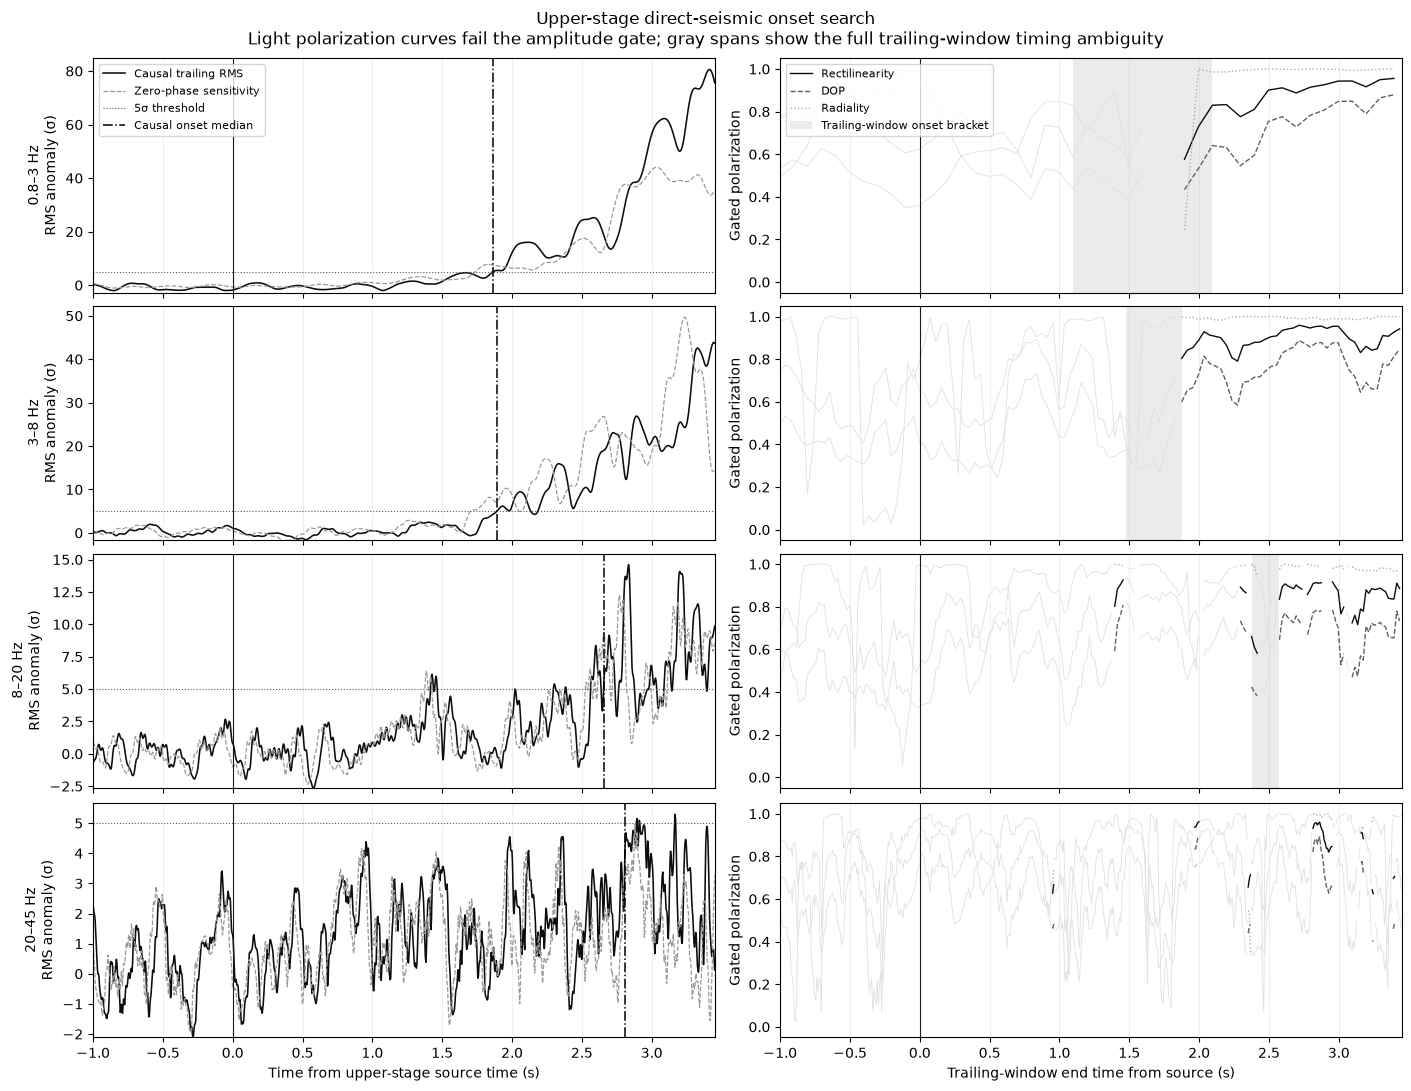

Saved: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/140_search_for_direct_seismic_waves/upper_stage_onset_and_polarization.pdf


In [7]:
fig, axes = plt.subplots(
    len(DIRECT_SEARCH_BANDS),
    2,
    figsize=(14, 2.7 * len(DIRECT_SEARCH_BANDS)),
    sharex=True,
    constrained_layout=True,
)

for row_index, (band_name, controls) in enumerate(DIRECT_SEARCH_BANDS.items()):
    envelope_ax, polarization_ax = axes[row_index]
    causal = band_products[band_name]["causal"]
    zero_phase = band_products[band_name]["zero_phase"]

    envelope_ax.plot(
        causal["time_s"], causal["rms_sigma"],
        color="0.05", lw=1.15, label="Causal trailing RMS",
    )
    envelope_ax.plot(
        zero_phase["time_s"], zero_phase["rms_sigma"],
        color="0.60", lw=0.9, ls="--", label="Zero-phase sensitivity",
    )
    envelope_ax.axhline(5.0, color="0.35", lw=0.8, ls=":", label="5σ threshold")
    summary_row = onset_summary.loc[onset_summary["band"] == band_name].iloc[0]
    onset_s = float(summary_row["causal_threshold_onset_median_s"])
    if np.isfinite(onset_s):
        envelope_ax.axvline(onset_s, color="black", lw=1.1, ls="-.", label="Causal onset median")
    envelope_ax.set_ylabel(f"{controls['freqmin_hz']:g}–{controls['freqmax_hz']:g} Hz\nRMS anomaly (σ)")
    envelope_ax.set_ylim(bottom=min(-1.0, float(np.nanmin(causal["rms_sigma"]))))
    envelope_ax.grid(True, axis="x", alpha=0.18)

    frame = trailing_polarization.loc[trailing_polarization["band"] == band_name]
    gated = frame["amplitude_gate"].to_numpy(bool)
    x = frame["window_end_s"].to_numpy(float)
    for column, label, color, linestyle in (
        ("rectilinearity", "Rectilinearity", "0.05", "-"),
        ("degree_of_polarization", "DOP", "0.38", "--"),
        ("radiality", "Radiality", "0.68", ":"),
    ):
        values = frame[column].to_numpy(float)
        polarization_ax.plot(x, np.where(gated, values, np.nan), color=color, ls=linestyle, lw=1.0, label=label)
        polarization_ax.plot(x, np.where(~gated, values, np.nan), color="0.88", lw=0.6)

    pol_row = polarization_summary.loc[polarization_summary["band"] == band_name].iloc[0]
    lower = float(pol_row["possible_onset_lower_bound_s"])
    upper = float(pol_row["possible_onset_upper_bound_s"])
    if np.isfinite(lower) and np.isfinite(upper):
        polarization_ax.axvspan(lower, upper, color="0.70", alpha=0.25, lw=0, label="Trailing-window onset bracket")
    polarization_ax.set_ylim(-0.05, 1.05)
    polarization_ax.set_ylabel("Gated polarization")
    polarization_ax.grid(True, axis="x", alpha=0.18)

    for ax in (envelope_ax, polarization_ax):
        ax.axvline(0.0, color="0.10", lw=0.8)
        ax.axvline(PREDICTED_ACOUSTIC_DELAY_S, color="0.55", lw=0.8, ls="--")
        ax.axvline(LOWER_STAGE_SOURCE_OFFSET_S, color="0.70", lw=0.7, ls=":")
        ax.set_xlim(*DISPLAY_WINDOW_S)

axes[0, 0].legend(loc="upper left", fontsize=8)
axes[0, 1].legend(loc="upper left", fontsize=8)
axes[-1, 0].set_xlabel("Time from upper-stage source time (s)")
axes[-1, 1].set_xlabel("Trailing-window end time from source (s)")
fig.suptitle(
    "Upper-stage direct-seismic onset search\n"
    "Light polarization curves fail the amplitude gate; gray spans show the full trailing-window timing ambiguity"
)
fig.savefig(ONSET_FIGURE, dpi=240, bbox_inches="tight")
plt.show()
print("Saved:", ONSET_FIGURE)


## 8. Component-energy and Z–R phase diagnostics


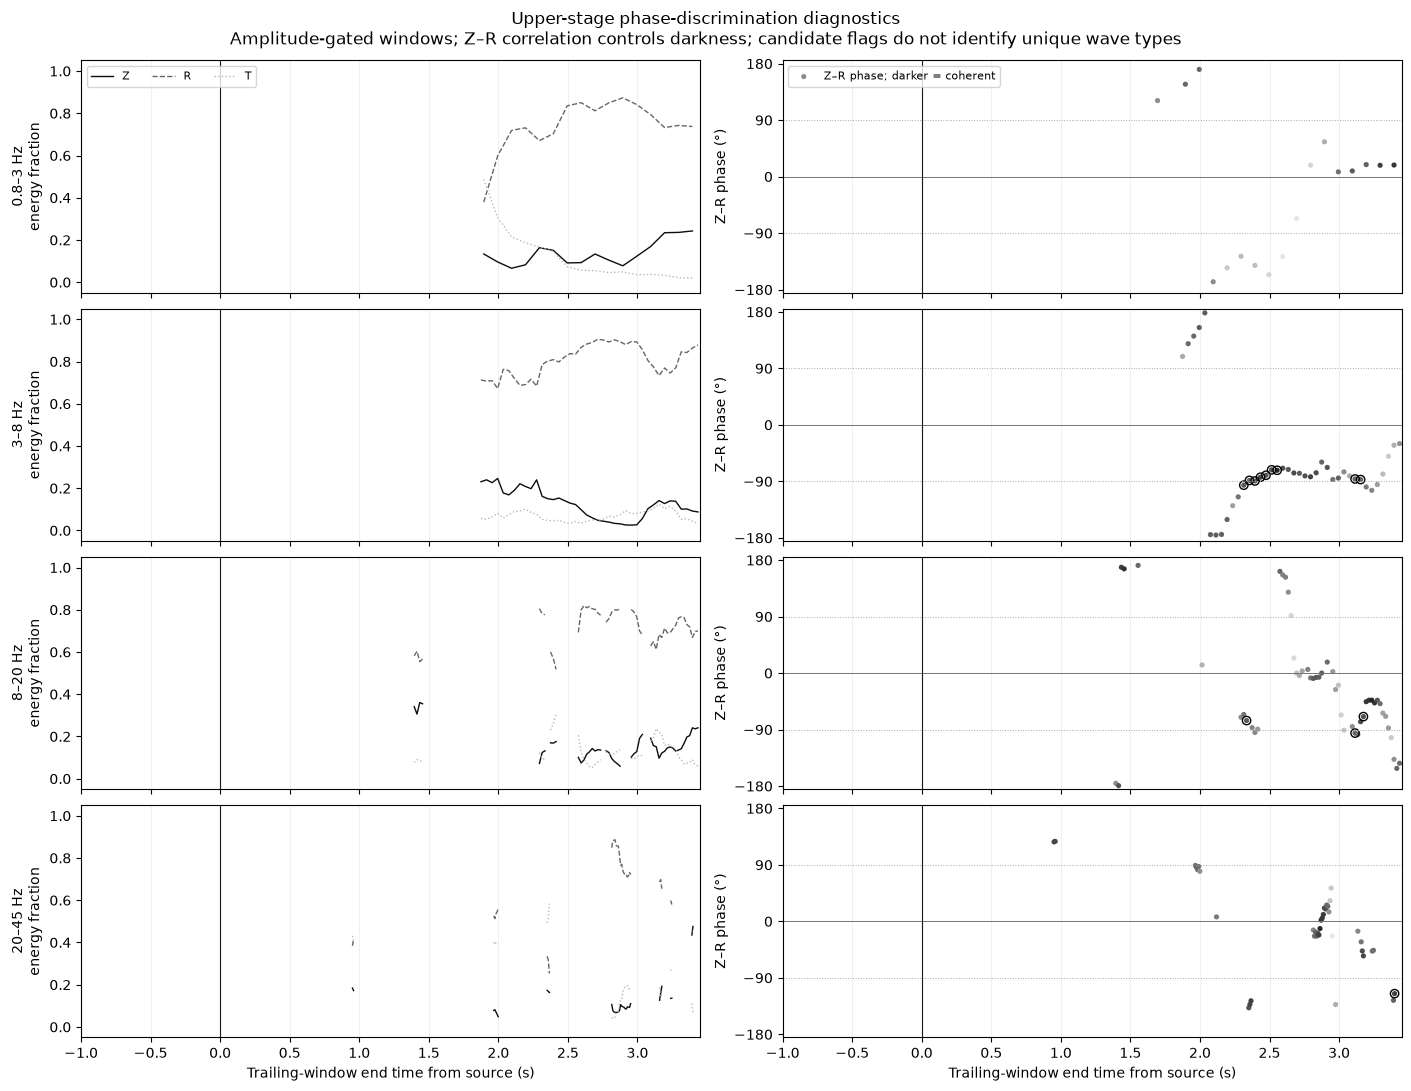

Saved: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/140_search_for_direct_seismic_waves/upper_stage_phase_discrimination.pdf


In [8]:
fig, axes = plt.subplots(
    len(DIRECT_SEARCH_BANDS),
    2,
    figsize=(14, 2.7 * len(DIRECT_SEARCH_BANDS)),
    sharex=True,
    constrained_layout=True,
)

for row_index, (band_name, controls) in enumerate(DIRECT_SEARCH_BANDS.items()):
    energy_ax, phase_ax = axes[row_index]
    frame = trailing_polarization.loc[
        trailing_polarization["band"] == band_name
    ].copy()
    x = frame["window_end_s"].to_numpy(float)
    gated = frame["amplitude_gate"].to_numpy(bool)

    for column, label, color, linestyle in (
        ("vertical_energy_fraction", "Z", "0.05", "-"),
        ("radial_energy_fraction", "R", "0.40", "--"),
        ("transverse_energy_fraction", "T", "0.72", ":"),
    ):
        values = frame[column].to_numpy(float)
        energy_ax.plot(
            x,
            np.where(gated, values, np.nan),
            color=color,
            ls=linestyle,
            lw=1.0,
            label=label,
        )
    energy_ax.set_ylim(-0.05, 1.05)
    energy_ax.set_ylabel(
        f"{controls['freqmin_hz']:g}–{controls['freqmax_hz']:g} Hz\nenergy fraction"
    )
    energy_ax.grid(True, axis="x", alpha=0.18)

    coherence = frame["zr_coherence"].to_numpy(float)
    phase = frame["zr_phase_deg"].to_numpy(float)
    significant = gated & np.isfinite(coherence) & np.isfinite(phase)
    gray = np.clip(1.0 - 0.90 * coherence[significant], 0.05, 0.90)
    phase_ax.scatter(
        x[significant],
        phase[significant],
        c=gray,
        cmap="gray",
        vmin=0.0,
        vmax=1.0,
        s=14,
        edgecolors="none",
        label="Z–R phase; darker = coherent",
    )
    phase_ax.axhline(90.0, color="0.65", lw=0.7, ls=":")
    phase_ax.axhline(-90.0, color="0.65", lw=0.7, ls=":")
    phase_ax.axhline(0.0, color="0.45", lw=0.7)
    phase_ax.set_ylim(-185, 185)
    phase_ax.set_yticks([-180, -90, 0, 90, 180])
    phase_ax.set_ylabel("Z–R phase (°)")
    phase_ax.grid(True, axis="x", alpha=0.18)

    rayleigh = frame["rayleigh_like"].to_numpy(bool)
    love = frame["love_like"].to_numpy(bool)
    if np.any(rayleigh):
        phase_ax.scatter(
            x[rayleigh], phase[rayleigh],
            marker="o", facecolors="none", edgecolors="black", s=36,
            label="Z–R quadrature candidate",
        )
    if np.any(love):
        energy_ax.scatter(
            x[love], frame.loc[love, "transverse_energy_fraction"],
            marker="s", facecolors="none", edgecolors="black", s=36,
            label="Transverse-dominant candidate",
        )

    for ax in (energy_ax, phase_ax):
        ax.axvline(0.0, color="0.10", lw=0.8)
        ax.axvline(LOWER_STAGE_SOURCE_OFFSET_S, color="0.70", lw=0.7, ls=":")
        ax.set_xlim(*DISPLAY_WINDOW_S)

axes[0, 0].legend(loc="upper left", fontsize=8, ncol=3)
axes[0, 1].legend(loc="upper left", fontsize=8)
axes[-1, 0].set_xlabel("Trailing-window end time from source (s)")
axes[-1, 1].set_xlabel("Trailing-window end time from source (s)")
fig.suptitle(
    "Upper-stage phase-discrimination diagnostics\n"
    "Amplitude-gated windows; Z–R correlation controls darkness; candidate flags do not identify unique wave types"
)
fig.savefig(PHASE_DIAGNOSTIC_FIGURE, dpi=240, bbox_inches="tight")
plt.show()
print("Saved:", PHASE_DIAGNOSTIC_FIGURE)


## 9. Noise-normalized focused Z/R/T spectrogram


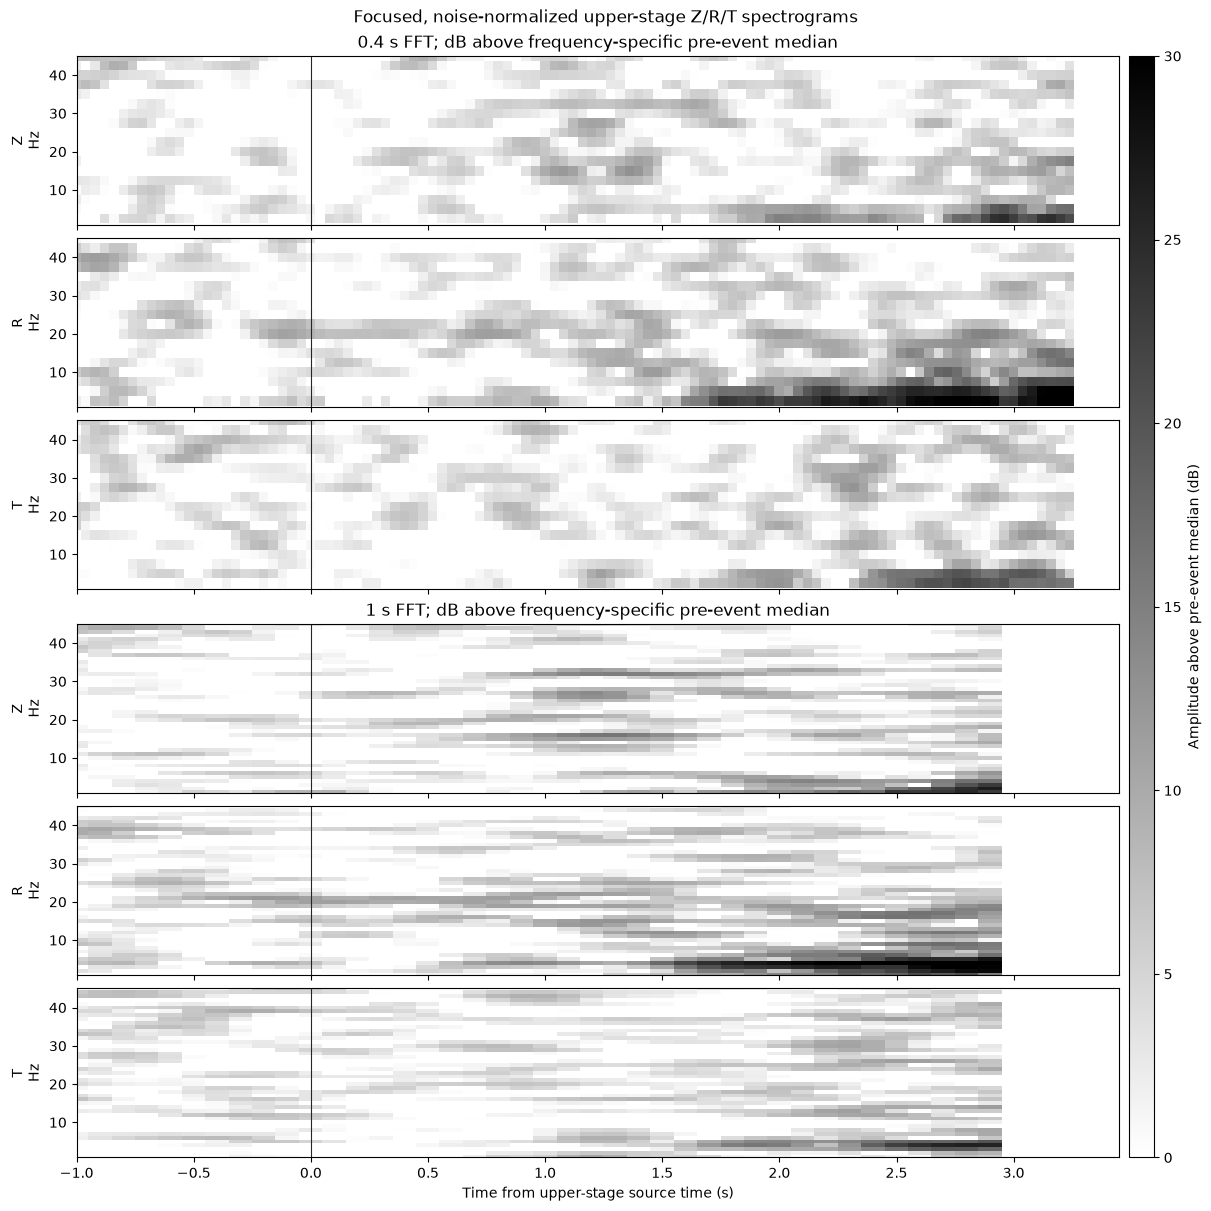

Saved: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/140_search_for_direct_seismic_waves/upper_stage_noise_normalized_spectrogram.pdf


In [9]:
def local_unfiltered_arrays() -> tuple[np.ndarray, dict[str, np.ndarray]]:
    local = st_zrt.copy().trim(
        UPPER_STAGE_SOURCE_TIME + NOISE_WINDOW_S[0],
        UPPER_STAGE_SOURCE_TIME + FOCUSED_END_S,
        pad=False,
    )
    local.detrend("linear")
    local.detrend("demean")
    return component_data(local, UPPER_STAGE_SOURCE_TIME)


raw_time_s, raw_data = local_unfiltered_arrays()
fft_windows_s = (0.40, 1.00)
fig, axes = plt.subplots(
    len(fft_windows_s) * 3,
    1,
    figsize=(12, 12),
    sharex=True,
    constrained_layout=True,
)

for window_index, fft_window_s in enumerate(fft_windows_s):
    nperseg = max(16, int(round(fft_window_s * SAMPLING_RATE_HZ)))
    noverlap = int(round(0.90 * nperseg))
    for component_index, component in enumerate("ZRT"):
        ax = axes[3 * window_index + component_index]
        frequency_hz, stft_time_s, amplitude = spectrogram(
            raw_data[component],
            fs=SAMPLING_RATE_HZ,
            window="hann",
            nperseg=nperseg,
            noverlap=noverlap,
            detrend="linear",
            scaling="spectrum",
            mode="magnitude",
        )
        stft_time_s = stft_time_s + raw_time_s[0]
        frequency_mask = (frequency_hz >= 0.8) & (frequency_hz <= 45.0)
        frequency_plot = frequency_hz[frequency_mask]
        amplitude_db = 20.0 * np.log10(
            np.maximum(amplitude[frequency_mask], np.finfo(float).tiny)
        )
        baseline = (
            (stft_time_s >= NOISE_WINDOW_S[0])
            & (stft_time_s <= NOISE_WINDOW_S[1])
        )
        baseline_median_db = np.nanmedian(amplitude_db[:, baseline], axis=1)
        excess_db = amplitude_db - baseline_median_db[:, None]
        mesh = ax.pcolormesh(
            stft_time_s,
            frequency_plot,
            excess_db,
            shading="auto",
            cmap="gray_r",
            vmin=0.0,
            vmax=30.0,
            rasterized=True,
        )
        ax.set_ylim(0.8, 45.0)
        ax.set_ylabel(f"{component}\nHz")
        ax.axvline(0.0, color="0.15", lw=0.8)
        ax.axvline(LOWER_STAGE_SOURCE_OFFSET_S, color="0.60", lw=0.7, ls=":")
        if component_index == 0:
            ax.set_title(f"{fft_window_s:g} s FFT; dB above frequency-specific pre-event median")

axes[-1].set_xlim(*DISPLAY_WINDOW_S)
axes[-1].set_xlabel("Time from upper-stage source time (s)")
cbar = fig.colorbar(mesh, ax=axes, pad=0.01, aspect=45)
cbar.set_label("Amplitude above pre-event median (dB)")
fig.suptitle("Focused, noise-normalized upper-stage Z/R/T spectrograms")
fig.savefig(SPECTROGRAM_FIGURE, dpi=240, bbox_inches="tight")
plt.show()
print("Saved:", SPECTROGRAM_FIGURE)


## 10. Frequency-dependent group-delay proxy

Zero-phase filtering is used here only to locate envelope maxima without causal filter delay. The first significant envelope maximum and the largest pre-contamination maximum are both retained. Their frequency-dependent travel times can suggest dispersion, but at one station they remain source-spectrum-dependent group-delay proxies rather than phase velocities.

Zero-phase filtering and Hilbert envelopes can spread energy backward from
later arrivals inside the padded record. A pre-airwave envelope peak therefore
does not establish a direct wave or dispersion. Frequency-dependent source
spectrum, site response, overlapping pulses and filter bandwidth also affect
these proxies. Confirm features against causal amplitude and raw waveforms.


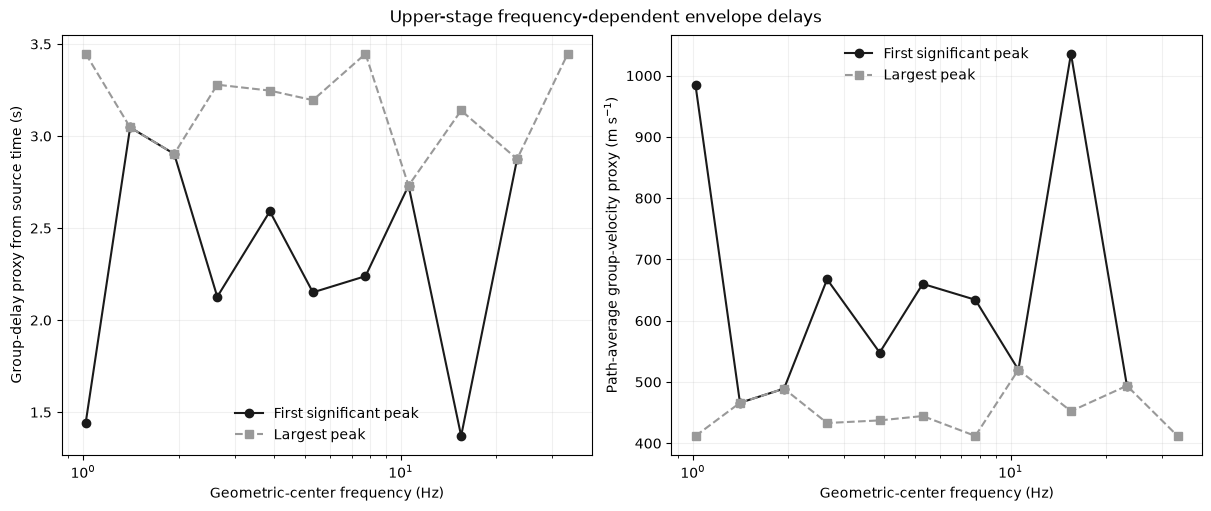

,freqmin_hz,freqmax_hz,geometric_center_frequency_hz,first_significant_peak_time_s,first_significant_peak_velocity_mps,largest_peak_time_s,largest_peak_velocity_mps,largest_peak_anomaly_sigma
0,0.8,1.3,1.019804,1.443,983.982336,3.447,411.919498,18.538593
1,1.1,1.8,1.407125,3.047,465.994917,3.047,465.994917,17.106524
2,1.5,2.5,1.936492,2.903,489.110062,2.903,489.110062,104.099397
3,2.0,3.5,2.645751,2.127,667.553602,3.279,433.024248,154.430385
4,3.0,5.0,3.872983,2.591,548.007144,3.247,437.291811,66.534498
5,4.0,7.0,5.291503,2.151,660.105305,3.195,444.408924,38.328259
6,6.0,10.0,7.745967,2.239,634.161014,3.447,411.919498,11.418632
7,8.0,14.0,10.583005,2.731,519.914504,2.731,519.914504,12.685627
8,12.0,20.0,15.491933,1.371,1035.657557,3.139,452.337213,10.589608
9,18.0,30.0,23.237900,2.875,493.873569,2.875,493.873569,5.380545


Saved: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/140_search_for_direct_seismic_waves/frequency_dependent_group_delay.csv
Saved: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/140_search_for_direct_seismic_waves/upper_stage_group_delay_proxy.pdf


In [10]:
group_delay_rows = []
group_delay_curves = []

for freqmin_hz, freqmax_hz in GROUP_DELAY_BANDS_HZ:
    filtered = prepare_filtered_stream(
        st_zrt,
        freqmin_hz=freqmin_hz,
        freqmax_hz=freqmax_hz,
        zerophase=True,
    )
    time_s, data = component_data(filtered, UPPER_STAGE_SOURCE_TIME)
    analytic_envelopes = {
        component: np.abs(hilbert(data[component]))
        for component in "ZRT"
    }
    envelope_3c = np.sqrt(sum(values ** 2 for values in analytic_envelopes.values()))
    smooth_s = max(0.04, 0.5 / np.sqrt(freqmin_hz * freqmax_hz))
    smooth_samples = max(1, int(round(smooth_s * SAMPLING_RATE_HZ)))
    envelope_3c = uniform_filter1d(envelope_3c, size=smooth_samples, mode="nearest")
    noise = (time_s >= NOISE_WINDOW_S[0]) & (time_s <= NOISE_WINDOW_S[1])
    noise_median, noise_sigma = robust_median_sigma(envelope_3c[noise])
    anomaly = (envelope_3c - noise_median) / noise_sigma
    search = (time_s >= SEARCH_WINDOW_S[0]) & (time_s <= FOCUSED_END_S)
    search_indices = np.flatnonzero(search)
    minimum_peak_distance = max(1, int(round(0.15 * SAMPLING_RATE_HZ)))
    local_peaks, properties = find_peaks(
        anomaly[search],
        height=5.0,
        prominence=2.0,
        distance=minimum_peak_distance,
    )
    absolute_peaks = search_indices[local_peaks] if len(local_peaks) else np.array([], dtype=int)
    first_peak_index = int(absolute_peaks[0]) if len(absolute_peaks) else None
    largest_peak_index = int(search_indices[np.nanargmax(anomaly[search])])

    first_peak_s = float(time_s[first_peak_index]) if first_peak_index is not None else np.nan
    largest_peak_s = float(time_s[largest_peak_index])
    center_hz = float(np.sqrt(freqmin_hz * freqmax_hz))
    group_delay_rows.append({
        "freqmin_hz": freqmin_hz,
        "freqmax_hz": freqmax_hz,
        "geometric_center_frequency_hz": center_hz,
        "first_significant_peak_time_s": first_peak_s,
        "first_significant_peak_velocity_mps": (
            SOURCE_TO_RECEIVER_DISTANCE_M / first_peak_s
            if np.isfinite(first_peak_s) and first_peak_s > 0 else np.nan
        ),
        "largest_peak_time_s": largest_peak_s,
        "largest_peak_velocity_mps": (
            SOURCE_TO_RECEIVER_DISTANCE_M / largest_peak_s
            if largest_peak_s > 0 else np.nan
        ),
        "largest_peak_anomaly_sigma": float(anomaly[largest_peak_index]),
    })
    group_delay_curves.append({
        "center_hz": center_hz,
        "time_s": time_s,
        "anomaly": anomaly,
    })

group_delay = pd.DataFrame(group_delay_rows)
group_delay.to_csv(GROUP_DELAY_TABLE, index=False)

fig, (ax_time, ax_speed) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
ax_time.plot(
    group_delay["geometric_center_frequency_hz"],
    group_delay["first_significant_peak_time_s"],
    "o-", color="0.10", label="First significant peak",
)
ax_time.plot(
    group_delay["geometric_center_frequency_hz"],
    group_delay["largest_peak_time_s"],
    "s--", color="0.60", label="Largest peak",
)
ax_time.set_xscale("log")
ax_time.set_xlabel("Geometric-center frequency (Hz)")
ax_time.set_ylabel("Group-delay proxy from source time (s)")
ax_time.grid(True, which="both", alpha=0.18)
ax_time.legend(frameon=False)

ax_speed.plot(
    group_delay["geometric_center_frequency_hz"],
    group_delay["first_significant_peak_velocity_mps"],
    "o-", color="0.10", label="First significant peak",
)
ax_speed.plot(
    group_delay["geometric_center_frequency_hz"],
    group_delay["largest_peak_velocity_mps"],
    "s--", color="0.60", label="Largest peak",
)
ax_speed.set_xscale("log")
ax_speed.set_xlabel("Geometric-center frequency (Hz)")
ax_speed.set_ylabel("Path-average group-velocity proxy (m s$^{-1}$)")
ax_speed.grid(True, which="both", alpha=0.18)
ax_speed.legend(frameon=False)
fig.suptitle("Upper-stage frequency-dependent envelope delays")
fig.savefig(GROUP_DELAY_FIGURE, dpi=240, bbox_inches="tight")
plt.show()

display(group_delay)
print("Saved:", GROUP_DELAY_TABLE)
print("Saved:", GROUP_DELAY_FIGURE)


## 11. Optional source-aligned stack of isolated A-quality events

This section uses the Notebook 100 measurement table when available. Events are retained only when sufficiently separated from both neighboring catalogue events. Each event envelope is standardized by its own pre-event noise, and the median is stacked so the largest explosion cannot dominate. Waveform polarity is not stacked because source mechanisms may differ.

The section is intentionally optional: absence of the Notebook 100 table does not invalidate the upper-stage analysis above.

Canonical catalogue epochs are DD2-referenced arrivals and require
source-to-DD2 travel-time subtraction before stacking by source time.
Isolation is judged from catalogue gaps, not proof of absent coda, unlisted
sources or prolonged signals. An A-quality infrasound direction does not
guarantee an isolated direct seismic phase.


Optional isolated A-quality events: 7


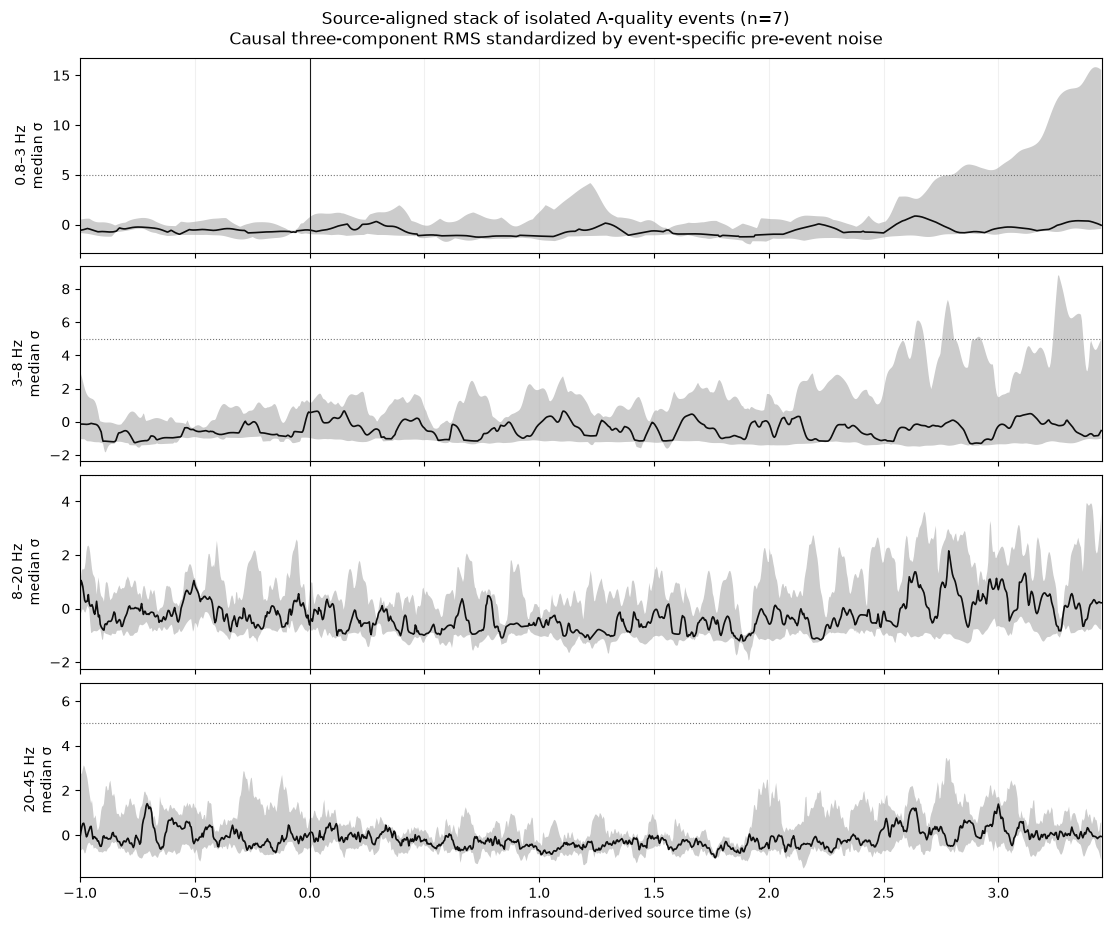

Saved: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/140_search_for_direct_seismic_waves/isolated_stack_events.csv
Saved: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/140_search_for_direct_seismic_waves/isolated_event_stack.csv
Saved: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/140_search_for_direct_seismic_waves/isolated_event_source_aligned_stack.pdf


In [11]:
CATALOGUE_CANDIDATES = (
    config.NB100_DIR / "event_acoustic_seismic_amplitudes.csv",
    config.NB080_DIR / "planar_array_results.csv",
)


def resolve_source_epoch(frame: pd.DataFrame) -> pd.Series:
    # Only explicitly source-labelled columns can be used without reduction.
    for column in ("estimated_source_time", "source_time_utc", "estimated_source_epoch_s"):
        if column in frame.columns:
            values = frame[column]
            if pd.api.types.is_numeric_dtype(values):
                return pd.to_numeric(values, errors="coerce")
            parsed = pd.to_datetime(values, utc=True, errors="coerce")
            epoch = pd.Series(np.nan, index=frame.index, dtype=float)
            valid = parsed.notna()
            epoch.loc[valid] = parsed.loc[valid].astype("int64") / 1e9
            return epoch
    if "reduced_event_epoch_s" not in frame.columns:
        raise KeyError("Need an explicitly source-labelled epoch or the canonical DD2 catalogue arrival epoch")
    geometry = pd.read_csv(Path(analysis_config["geometry_file"]).expanduser())
    reference_channel = analysis_config["infrasound_reference_channel"]
    reference_rows = geometry.loc[geometry.channel.eq(reference_channel)]
    if len(reference_rows) != 1:
        raise ValueError("Need one catalogue reference sensor distance")
    reference_travel_s = float(reference_rows.iloc[0].distance_m) / METEOROLOGICAL_EFFECTIVE_SOUND_SPEED_MPS
    return pd.to_numeric(frame["reduced_event_epoch_s"], errors="coerce") - reference_travel_s


catalogue_file = next((path for path in CATALOGUE_CANDIDATES if path.exists()), None)
stack_created = False

if catalogue_file is None:
    print("Optional stack skipped: no Notebook 100/080 event table was found")
else:
    catalogue = pd.read_csv(catalogue_file)
    if "solution_quality_class" not in catalogue.columns:
        print("Optional stack skipped: catalogue lacks solution_quality_class")
    else:
        catalogue = catalogue.copy()
        catalogue["source_epoch_s"] = resolve_source_epoch(catalogue)
        catalogue = catalogue.loc[
            (catalogue["solution_quality_class"] == STACK_QUALITY_CLASS)
            & np.isfinite(catalogue["source_epoch_s"])
        ].sort_values("source_epoch_s").drop_duplicates("source_epoch_s")

        all_times = np.sort(resolve_source_epoch(pd.read_csv(catalogue_file)).dropna().to_numpy(float))
        previous_gap = np.full(len(catalogue), np.inf)
        next_gap = np.full(len(catalogue), np.inf)
        catalogue_times = catalogue["source_epoch_s"].to_numpy(float)
        for index, event_epoch in enumerate(catalogue_times):
            earlier = all_times[all_times < event_epoch]
            later = all_times[all_times > event_epoch]
            if len(earlier):
                previous_gap[index] = event_epoch - earlier[-1]
            if len(later):
                next_gap[index] = later[0] - event_epoch
        catalogue["previous_event_gap_s"] = previous_gap
        catalogue["next_event_gap_s"] = next_gap
        isolated = catalogue.loc[
            (catalogue["previous_event_gap_s"] >= STACK_PREVIOUS_EVENT_GAP_S)
            & (catalogue["next_event_gap_s"] >= STACK_NEXT_EVENT_GAP_S)
        ].head(STACK_MAX_EVENTS).copy()

        stream_start_epoch = float(min(tr.stats.starttime.timestamp for tr in st_zrt))
        stream_end_epoch = float(max(tr.stats.endtime.timestamp for tr in st_zrt))
        isolated = isolated.loc[
            (isolated["source_epoch_s"] + NOISE_WINDOW_S[0] >= stream_start_epoch)
            & (isolated["source_epoch_s"] + FOCUSED_END_S <= stream_end_epoch)
        ].copy()

        isolated.to_csv(STACK_EVENT_TABLE, index=False)
        print(f"Optional isolated A-quality events: {len(isolated)}")

        if len(isolated) < STACK_MIN_EVENTS:
            print(
                f"Stack skipped: need at least {STACK_MIN_EVENTS} isolated events; "
                f"found {len(isolated)}"
            )
        else:
            stack_rows = []
            fig, axes = plt.subplots(
                len(DIRECT_SEARCH_BANDS), 1,
                figsize=(11, 2.3 * len(DIRECT_SEARCH_BANDS)),
                sharex=True, constrained_layout=True,
            )
            for ax, (band_name, controls) in zip(np.atleast_1d(axes), DIRECT_SEARCH_BANDS.items()):
                standardized_series = []
                for event in isolated.itertuples(index=False):
                    event_time = UTCDateTime(float(event.source_epoch_s))
                    filtered = prepare_filtered_stream(
                        st_zrt,
                        freqmin_hz=controls["freqmin_hz"],
                        freqmax_hz=controls["freqmax_hz"],
                        zerophase=False,
                        reference_time=event_time,
                    )
                    time_s, data = component_data(filtered, event_time)
                    rms = causal_three_component_rms(
                        data, controls["rms_smooth_s"], SAMPLING_RATE_HZ
                    )
                    noise = (time_s >= NOISE_WINDOW_S[0]) & (time_s <= NOISE_WINDOW_S[1])
                    median, sigma = robust_median_sigma(rms[noise])
                    standardized_series.append((
                        np.asarray(time_s, dtype=float),
                        np.asarray((rms - median) / sigma, dtype=float),
                    ))

                # Event origins need not coincide with the 250-Hz sample grid,
                # so otherwise identical trims can differ by one sample. Build
                # an explicit relative-time grid over the common intersection
                # and interpolate every standardized event onto it.
                common_start_s = max(series_time[0] for series_time, _ in standardized_series)
                common_end_s = min(series_time[-1] for series_time, _ in standardized_series)
                first_sample = int(np.ceil(common_start_s * SAMPLING_RATE_HZ - 1.0e-9))
                last_sample = int(np.floor(common_end_s * SAMPLING_RATE_HZ + 1.0e-9))
                if last_sample <= first_sample:
                    raise ValueError(
                        f"No common stack interval for band {band_name}: "
                        f"{common_start_s:.6f} to {common_end_s:.6f} s"
                    )
                common_time = (
                    np.arange(first_sample, last_sample + 1, dtype=float)
                    / SAMPLING_RATE_HZ
                )
                standardized = [
                    np.interp(
                        common_time,
                        series_time,
                        series_values,
                    )
                    for series_time, series_values in standardized_series
                ]
                matrix = np.vstack(standardized)
                median_stack = np.nanmedian(matrix, axis=0)
                low_stack = np.nanpercentile(matrix, 16, axis=0)
                high_stack = np.nanpercentile(matrix, 84, axis=0)
                ax.fill_between(common_time, low_stack, high_stack, color="0.80", lw=0)
                ax.plot(common_time, median_stack, color="0.05", lw=1.2)
                ax.axhline(5.0, color="0.45", ls=":", lw=0.8)
                ax.axvline(0.0, color="0.10", lw=0.8)
                ax.set_ylabel(f"{controls['freqmin_hz']:g}–{controls['freqmax_hz']:g} Hz\nmedian σ")
                ax.grid(True, axis="x", alpha=0.18)
                for time_value, median_value, low_value, high_value in zip(
                    common_time, median_stack, low_stack, high_stack
                ):
                    stack_rows.append({
                        "band": band_name,
                        "time_from_source_s": float(time_value),
                        "event_count": int(len(isolated)),
                        "median_noise_standardized_rms": float(median_value),
                        "percentile_16": float(low_value),
                        "percentile_84": float(high_value),
                    })

            axes[-1].set_xlim(*DISPLAY_WINDOW_S)
            axes[-1].set_xlabel("Time from infrasound-derived source time (s)")
            fig.suptitle(
                f"Source-aligned stack of isolated A-quality events (n={len(isolated)})\n"
                "Causal three-component RMS standardized by event-specific pre-event noise"
            )
            fig.savefig(STACK_FIGURE, dpi=240, bbox_inches="tight")
            plt.show()
            pd.DataFrame(stack_rows).to_csv(STACK_LONG_TABLE, index=False)
            stack_created = True
            print("Saved:", STACK_EVENT_TABLE)
            print("Saved:", STACK_LONG_TABLE)
            print("Saved:", STACK_FIGURE)


## 12. Interpretation rules and uncertainty

Use the following hierarchy when interpreting the executed results:

1. **Arrival onset:** prefer a persistent causal-amplitude onset that is reproduced in adjacent bands.
2. **Polarization confirmation:** require amplitude-gated, stable polarization. The trailing-window bracket—not merely its end time—is the timing constraint.
3. **P-like evidence:** early, rectilinear motion in the radial plane, with plausible incidence and low transverse fraction.
4. **S-like evidence:** a later repeatable change toward transverse SH motion or distinct SV polarization. Radial-plane motion alone cannot separate P from SV.
5. **Rayleigh-like evidence:** high Z–R coherence, systematic near-quadrature phase, appreciable Z and R energy, and frequency-dependent group delay.
6. **Love-like evidence:** transverse dominance with little vertical energy.

For an onset travel time $t$ and distance $d$, report

$$v=d/t,$$

with uncertainty propagated as

$$\frac{\sigma_v}{v}\simeq\sqrt{\left(\frac{\sigma_d}{d}\right)^2+\left(\frac{\sigma_t}{t}\right)^2}.$$

The source-time uncertainty must include the infrasound arrival pick, the 351 m s$^{-1}$ source-reduction model, and any residual clock correction. Filter-choice and detector-choice spread should be included in $\sigma_t$. Do not report a P, S, or Rayleigh speed unless the phase interpretation survives these tests.


## 13. Write summary and validate outputs


In [12]:
summary = {
    "producer_notebook": "140_search_for_direct_seismic_waves.ipynb",
    "source_notebook12_zrt_stream": str(ZRT_STREAM_FILE),
    "reference_description": "source-to-BCHH seismometer distance; geographic Z/R/T orientation inherited from 130",
    "source_epoch_policy": "named origins adopted from config; catalogue DD2 arrivals reduced by geometry/weather travel time before optional stack",
    "phase_definitions": "none introduced or modified",
    "gap_policy": "complete finite aligned samples; no interpolation",
    "polarization_analytic_support": "Hilbert transform confined to each trailing window; finite-window edge effects remain",
    "threshold_interpretation": "robust-MAD empirical levels; not Gaussian significance or calibrated false-alarm probability",
    "search_controls": DIRECT_SEARCH_BANDS,
    "quadrature_minimum_z_and_r_energy_fraction": POLARIZATION_MIN_ZR_ENERGY_FRACTION,
    "noise_window_s": list(NOISE_WINDOW_S),
    "amplitude_thresholds": list(AMPLITUDE_SIGMA_THRESHOLDS),
    "event_key": EVENT_KEY,
    "source_time_utc": str(UPPER_STAGE_SOURCE_TIME),
    "source_to_receiver_distance_m": SOURCE_TO_RECEIVER_DISTANCE_M,
    "meteorological_effective_sound_speed_mps": METEOROLOGICAL_EFFECTIVE_SOUND_SPEED_MPS,
    "predicted_acoustic_delay_s": PREDICTED_ACOUSTIC_DELAY_S,
    "next_named_source_offset_s": LOWER_STAGE_SOURCE_OFFSET_S,
    "focused_search_end_s": FOCUSED_END_S,
    "sampling_rate_hz": SAMPLING_RATE_HZ,
    "filtering": {
        "onset_authority": "causal two-corner Butterworth bandpass",
        "zero_phase_use": "sensitivity and group-delay morphology only",
    },
    "interpretation_limit": (
        "Single-station timing provides path-average apparent velocity or "
        "frequency-dependent group-delay proxies, not independent phase velocity."
    ),
    "stack_created": bool(stack_created),
    "outputs": {
        "onset_candidates": str(ONSET_CANDIDATE_TABLE),
        "onset_summary": str(ONSET_SUMMARY_TABLE),
        "trailing_polarization": str(POLARIZATION_TABLE),
        "polarization_summary": str(POLARIZATION_SUMMARY_TABLE),
        "group_delay": str(GROUP_DELAY_TABLE),
        "onset_figure": str(ONSET_FIGURE),
        "phase_diagnostic_figure": str(PHASE_DIAGNOSTIC_FIGURE),
        "spectrogram_figure": str(SPECTROGRAM_FIGURE),
        "group_delay_figure": str(GROUP_DELAY_FIGURE),
    },
}
if stack_created:
    summary["outputs"].update({
        "stack_events": str(STACK_EVENT_TABLE),
        "stack_long_table": str(STACK_LONG_TABLE),
        "stack_figure": str(STACK_FIGURE),
    })

SUMMARY_JSON.write_text(json.dumps(summary, indent=2) + "\n")

required_outputs = (
    ONSET_CANDIDATE_TABLE,
    ONSET_SUMMARY_TABLE,
    POLARIZATION_TABLE,
    POLARIZATION_SUMMARY_TABLE,
    GROUP_DELAY_TABLE,
    ONSET_FIGURE,
    PHASE_DIAGNOSTIC_FIGURE,
    SPECTROGRAM_FIGURE,
    GROUP_DELAY_FIGURE,
    SUMMARY_JSON,
)
for path in required_outputs:
    if not Path(path).exists():
        raise FileNotFoundError(path)
    print(path)


/Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/140_search_for_direct_seismic_waves/onset_candidates.csv
/Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/140_search_for_direct_seismic_waves/onset_summary_by_band.csv
/Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/140_search_for_direct_seismic_waves/trailing_polarization.csv
/Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/140_search_for_direct_seismic_waves/polarization_confirmation_summary.csv
/Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/140_search_for_direct_seismic_waves/frequency_dependent_group_delay.csv
/Users/glennthompson/Developer/KSCRocketSeismoHy